In [ ]:
pip install pymatgen

In [ ]:
pip install matminer

In [ ]:
pip install ase

In [ ]:
%%capture
!apt install python3-mpi4py cython3 libxc-dev gpaw-data
!pip -q install gpaw

Empty DataFrame
Columns: [formula, bulk_modulus, structure]
Index: []
Invalid formulas found and removed: ['2-Feb', '2-Feb', nan, '4-Feb']
Cleaned dataset size: 10990


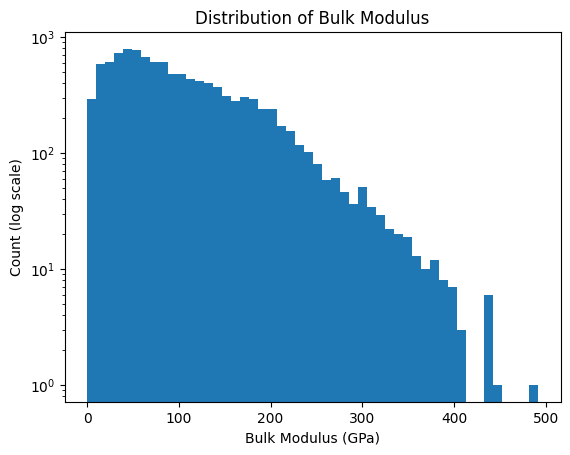

Cleaned dataset size: 10990


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core import Composition, Structure, Lattice

df = pd.read_csv("polished csv bulk modulus v1.csv")

# Convert bulk_modulus to numeric
df['bulk_modulus'] = pd.to_numeric(df['bulk_modulus'], errors='coerce')

# Remove missing or invalid values (e.g., negative bulk modulus)
df = df.dropna(subset=["bulk_modulus"])
df = df[df["bulk_modulus"] > 0]  # Physical constraint

# Check for exact duplicates (keep all polymorphs)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)
if not duplicates.empty:
    df = df.drop_duplicates()

# Filter out invalid formulas
def is_valid_formula(f):
    try:
        Composition(f)
        return True
    except ValueError:
        return False

invalid = df[~df["formula"].apply(is_valid_formula)]
if not invalid.empty:
    print("Invalid formulas found and removed:", invalid["formula"].tolist())

df = df[df["formula"].apply(is_valid_formula)]

# Parse structure strings to pymatgen Structure objects
def parse_structure_str(s):
    lines = s.splitlines()
    i = 0
    a = b = c = alpha = beta = gamma = None
    pbc = [True, True, True]  # default
    species = []
    coords = []
    magmoms = []
    has_magmom = False
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        if line.startswith('abc'):
            parts = line.split()
            a = float(parts[2])
            b = float(parts[3])
            c = float(parts[4])
        elif line.startswith('angles'):
            parts = line.split()
            alpha = float(parts[1])
            beta = float(parts[2])
            gamma = float(parts[3])
        elif line.startswith('pbc'):
            parts = line.split()
            pbc = [parts[2] == 'True', parts[3] == 'True', parts[4] == 'True']
        elif line.startswith('Sites'):
            i += 1
            header_line = lines[i].strip()
            header = header_line.split()
            has_magmom = header[-1] == 'magmom'
            i += 1
            if lines[i].strip().startswith('---'):
                i += 1
            while i < len(lines):
                data_line = lines[i].strip()
                if not data_line or data_line.startswith('"'):
                    break
                parts = data_line.split()
                sp = parts[1]
                a_frac = float(parts[2])
                b_frac = float(parts[3])
                c_frac = float(parts[4])
                species.append(sp)
                coords.append([a_frac, b_frac, c_frac])
                if has_magmom:
                    mag = float(parts[5])
                    magmoms.append(mag)
                i += 1
            break  # after sites
        i += 1
    if a is None or alpha is None:
        raise ValueError("Missing lattice parameters")
    lattice = Lattice.from_parameters(a, b, c, alpha, beta, gamma)
    site_props = {'magmom': magmoms} if has_magmom and magmoms else {}
    struct = Structure(lattice, species, coords, site_properties=site_props)
    return struct

def safe_parse(s):
    try:
        return parse_structure_str(s)
    except Exception as e:
        print(f"Parsing error: {e}")
        return None

df['structure_obj'] = df['structure'].apply(safe_parse)
df = df.dropna(subset=['structure_obj'])

# Elemental prevalence (optional: check bias)
elements = [list(Composition(f).elements) for f in df["formula"]]
# Flatten and count (use collections.Counter for details)

print(f"Cleaned dataset size: {len(df)}")

# Explore distribution
plt.hist(df["bulk_modulus"], bins=50, log=True)
plt.xlabel("Bulk Modulus (GPa)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Bulk Modulus")
plt.show()
# Elemental prevalence (optional: check bias)
elements = [list(Composition(f).elements) for f in df["formula"]]
# Flatten and count (use collections.Counter for details)

print(f"Cleaned dataset size: {len(df)}")

In [11]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
# Get composition from structure
df['composition'] = df['structure_obj'].apply(lambda s: s.composition)

# Composition features (e.g., Magpie preset from matminer)
ep_feat = ElementProperty.from_preset("magpie")
df_comp = ep_feat.featurize_dataframe(df, col_id="composition", ignore_errors=True)

# Structure features (density, packing fraction)
dens_feat = DensityFeatures()
df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

# Features (X) and target (y)
to_drop = ["formula", "bulk_modulus", "structure", "structure_obj", "composition"]
feature_cols = [col for col in df_struct.columns if col not in to_drop]
X = np.asarray(df_struct[feature_cols])  # Safe conversion: works for DataFrame or ndarray
y = np.asarray(df_struct["bulk_modulus"])

# Handle any NaNs introduced by featurization
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)
import joblib
joblib.dump(imputer, 'imputer.pkl')
print(f"Feature matrix shape: {X.shape}")

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/10990 [00:00<?, ?it/s]

DensityFeatures:   0%|          | 0/10990 [00:00<?, ?it/s]

Feature matrix shape: (10990, 135)


In [7]:
pip install catboost

Application of Machine Learning Algorithms

In [ ]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib  # For Random Forest dump, if needed

# Assume X and y are defined elsewhere (your dataset)

# Log-transform target (for log-normal distribution)
y_log = np.log1p(y)  # log(1 + y) to handle zeros if any

# Start total timing for the entire process
total_start = time.time()

# Split: 70% train, 15% val, 15% test
split_start = time.time()
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
split_end = time.time()
print(f"Data splitting time: {split_end - split_start:.4f} seconds")

# Scale features (fit on train only)
scale_start = time.time()
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
scale_end = time.time()
print(f"Feature scaling time: {scale_end - scale_start:.4f} seconds")

# Combine train and val for grid search
X_train_val_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.hstack([y_train, y_val])

# --- Random Forest ---
print("\n--- Random Forest ---")
rf_start = time.time()

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring="neg_mean_squared_error")
grid_search_rf.fit(X_train_val_scaled, y_train_val)

best_rf = grid_search_rf.best_estimator_
print(f"Best params: {grid_search_rf.best_params_}")

# Optional: Save model and scaler (from original RF code)
joblib.dump(best_rf, 'best_rf.pkl')
joblib.dump(scaler_X, 'scaler_x.pkl')

# Evaluate on test set (added for consistency)
eval_start = time.time()
y_pred_log = best_rf.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

rf_end = time.time()
rf_grid_time = rf_end - rf_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {rf_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_rf = len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split']) * 5
time_per_fit_rf = rf_grid_time / num_fits_rf if num_fits_rf > 0 else 0
print(f"Average time per model fit: {time_per_fit_rf:.4f} seconds")

# --- Support Vector Machine ---
print("\n--- Support Vector Machine ---")
svm_start = time.time()

svr = SVR()

param_grid_svm = {
    "kernel": ["rbf"],
    "C": [1, 10],
    "epsilon": [0.1],
    "gamma": ["scale"]
}

grid_search_svm = GridSearchCV(svr, param_grid_svm, cv=5, scoring="neg_mean_squared_error")
grid_search_svm.fit(X_train_val_scaled, y_train_val)

best_svr = grid_search_svm.best_estimator_
print(f"Best params: {grid_search_svm.best_params_}")
joblib.dump(best_svr, 'best_svr.pkl')

# Evaluate on test set (added for consistency)
eval_start = time.time()
y_pred_log = best_svr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

svm_end = time.time()
svm_grid_time = svm_end - svm_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {svm_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_svm = len(param_grid_svm['kernel']) * len(param_grid_svm['C']) * len(param_grid_svm['epsilon']) * len(param_grid_svm['gamma']) * 5
time_per_fit_svm = svm_grid_time / num_fits_svm if num_fits_svm > 0 else 0
print(f"Average time per model fit: {time_per_fit_svm:.4f} seconds")

# --- Gradient Boosted Regressor ---
print("\n--- Gradient Boosted Regressor ---")
gbr_start = time.time()

gbr = GradientBoostingRegressor(random_state=42)

param_grid_gbr = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "min_samples_split": [2, 5]
}

grid_search_gbr = GridSearchCV(gbr, param_grid_gbr, cv=5, scoring="neg_mean_squared_error")
grid_search_gbr.fit(X_train_val_scaled, y_train_val)

best_gbr = grid_search_gbr.best_estimator_
print(f"Best params: {grid_search_gbr.best_params_}")
joblib.dump(best_gbr, 'best_gbr.pkl')


# Evaluate on test set (added for consistency)
eval_start = time.time()
y_pred_log = best_gbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

gbr_end = time.time()
gbr_grid_time = gbr_end - gbr_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {gbr_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_gbr = len(param_grid_gbr['n_estimators']) * len(param_grid_gbr['max_depth']) * len(param_grid_gbr['learning_rate']) * len(param_grid_gbr['min_samples_split']) * 5
time_per_fit_gbr = gbr_grid_time / num_fits_gbr if num_fits_gbr > 0 else 0
print(f"Average time per model fit: {time_per_fit_gbr:.4f} seconds")

# --- XGBoost ---
print("\n--- XGBoost ---")
xgb_start = time.time()

xgbr = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgbr, param_grid_xgb, cv=5, scoring="neg_mean_squared_error")
grid_search_xgb.fit(X_train_val_scaled, y_train_val)

best_xgbr = grid_search_xgb.best_estimator_
print(f"Best params: {grid_search_xgb.best_params_}")
joblib.dump(best_xgbr, 'best_xgbr.pkl')

# Evaluate on test set
eval_start = time.time()
y_pred_log = best_xgbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

xgb_end = time.time()
xgb_grid_time = xgb_end - xgb_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {xgb_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_xgb = len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['min_child_weight']) * len(param_grid_xgb['subsample']) * 5
time_per_fit_xgb = xgb_grid_time / num_fits_xgb if num_fits_xgb > 0 else 0
print(f"Average time per model fit: {time_per_fit_xgb:.4f} seconds")

# --- CatBoost Regressor ---
print("\n--- CatBoost Regressor ---")
cat_start = time.time()

cbr = CatBoostRegressor(random_state=42, loss_function='RMSE')  # verbose=0 to suppress output during fits

param_grid_cat = {
    "iterations": [100, 200],
    "depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "l2_leaf_reg": [1, 3],
    "subsample": [0.8, 1.0]
}

grid_search_cat = GridSearchCV(cbr, param_grid_cat, cv=5, scoring="neg_mean_squared_error")
grid_search_cat.fit(X_train_val_scaled, y_train_val)

best_cbr = grid_search_cat.best_estimator_
print(f"Best params: {grid_search_cat.best_params_}")
joblib.dump(best_cbr, 'best_cbr.pkl')

# Evaluate on test set
eval_start = time.time()
y_pred_log = best_cbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

cat_end = time.time()
cat_grid_time = cat_end - cat_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {cat_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_cat = len(param_grid_cat['iterations']) * len(param_grid_cat['depth']) * len(param_grid_cat['learning_rate']) * len(param_grid_cat['l2_leaf_reg']) * len(param_grid_cat['subsample']) * 5
time_per_fit_cat = cat_grid_time / num_fits_cat if num_fits_cat > 0 else 0
print(f"Average time per model fit: {time_per_fit_cat:.4f} seconds")

# End total timing
total_end = time.time()
total_time = total_end - total_start
print(f"\nTotal execution time: {total_time:.4f} seconds")

In [12]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib  # For Random Forest dump, if needed

# Assume X and y are defined elsewhere (your dataset)

# Log-transform target (for log-normal distribution)
y_log = np.log1p(y)  # log(1 + y) to handle zeros if any

# Start total timing for the entire process
total_start = time.time()

# Split: 70% train, 15% val, 15% test
split_start = time.time()
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
split_end = time.time()
print(f"Data splitting time: {split_end - split_start:.4f} seconds")

# Scale features (fit on train only)
scale_start = time.time()
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
scale_end = time.time()
print(f"Feature scaling time: {scale_end - scale_start:.4f} seconds")

# Combine train and val for grid search
X_train_val_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.hstack([y_train, y_val])

print("\n--- Gradient Boosted Regressor ---")
gbr_start = time.time()

gbr = GradientBoostingRegressor(random_state=42)

param_grid_gbr = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "min_samples_split": [2, 5]
}

grid_search_gbr = GridSearchCV(gbr, param_grid_gbr, cv=5, scoring="neg_mean_squared_error")
grid_search_gbr.fit(X_train_val_scaled, y_train_val)

best_gbr = grid_search_gbr.best_estimator_
print(f"Best params: {grid_search_gbr.best_params_}")
joblib.dump(best_gbr, 'best_gbr.pkl')


# Evaluate on test set (added for consistency)
eval_start = time.time()
y_pred_log = best_gbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

gbr_end = time.time()
gbr_grid_time = gbr_end - gbr_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {gbr_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_gbr = len(param_grid_gbr['n_estimators']) * len(param_grid_gbr['max_depth']) * len(param_grid_gbr['learning_rate']) * len(param_grid_gbr['min_samples_split']) * 5
time_per_fit_gbr = gbr_grid_time / num_fits_gbr if num_fits_gbr > 0 else 0
print(f"Average time per model fit: {time_per_fit_gbr:.4f} seconds")

# --- XGBoost ---
print("\n--- XGBoost ---")
xgb_start = time.time()

xgbr = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgbr, param_grid_xgb, cv=5, scoring="neg_mean_squared_error")
grid_search_xgb.fit(X_train_val_scaled, y_train_val)

best_xgbr = grid_search_xgb.best_estimator_
print(f"Best params: {grid_search_xgb.best_params_}")
joblib.dump(best_xgbr, 'best_xgbr.pkl')

# Evaluate on test set
eval_start = time.time()
y_pred_log = best_xgbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

xgb_end = time.time()
xgb_grid_time = xgb_end - xgb_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {xgb_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_xgb = len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['min_child_weight']) * len(param_grid_xgb['subsample']) * 5
time_per_fit_xgb = xgb_grid_time / num_fits_xgb if num_fits_xgb > 0 else 0
print(f"Average time per model fit: {time_per_fit_xgb:.4f} seconds")

# --- CatBoost Regressor ---
print("\n--- CatBoost Regressor ---")
cat_start = time.time()

cbr = CatBoostRegressor(random_state=42, loss_function='RMSE')  # verbose=0 to suppress output during fits

param_grid_cat = {
    "iterations": [100, 200],
    "depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "l2_leaf_reg": [1, 3],
    "subsample": [0.8, 1.0]
}

grid_search_cat = GridSearchCV(cbr, param_grid_cat, cv=5, scoring="neg_mean_squared_error")
grid_search_cat.fit(X_train_val_scaled, y_train_val)

best_cbr = grid_search_cat.best_estimator_
print(f"Best params: {grid_search_cat.best_params_}")
joblib.dump(best_cbr, 'best_cbr.pkl')

# Evaluate on test set
eval_start = time.time()
y_pred_log = best_cbr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Back to original scale
y_test_orig = np.expm1(y_test)  # Compute original (non-log) test target
mse = mean_squared_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)
print(f"Test MSE: {mse}, R2: {r2}")
eval_end = time.time()
print(f"Evaluation time: {eval_end - eval_start:.4f} seconds")

cat_end = time.time()
cat_grid_time = cat_end - cat_start - (eval_end - eval_start)  # Approximate grid time excluding eval
print(f"Grid search fitting time: {cat_grid_time:.4f} seconds")

# Calculate efficiency metrics
num_fits_cat = len(param_grid_cat['iterations']) * len(param_grid_cat['depth']) * len(param_grid_cat['learning_rate']) * len(param_grid_cat['l2_leaf_reg']) * len(param_grid_cat['subsample']) * 5
time_per_fit_cat = cat_grid_time / num_fits_cat if num_fits_cat > 0 else 0
print(f"Average time per model fit: {time_per_fit_cat:.4f} seconds")

# End total timing
total_end = time.time()
total_time = total_end - total_start
print(f"\nTotal execution time: {total_time:.4f} seconds")

Streaming output truncated to the last 5000 lines.
7:	learn: 0.5493574	total: 111ms	remaining: 2.66s
8:	learn: 0.5251742	total: 126ms	remaining: 2.66s
9:	learn: 0.5027235	total: 155ms	remaining: 2.94s
10:	learn: 0.4809522	total: 172ms	remaining: 2.95s
11:	learn: 0.4626533	total: 185ms	remaining: 2.9s
12:	learn: 0.4464319	total: 197ms	remaining: 2.84s
13:	learn: 0.4318896	total: 210ms	remaining: 2.79s
14:	learn: 0.4188203	total: 229ms	remaining: 2.83s
15:	learn: 0.4060329	total: 244ms	remaining: 2.81s
16:	learn: 0.3959028	total: 257ms	remaining: 2.77s
17:	learn: 0.3849165	total: 272ms	remaining: 2.75s
18:	learn: 0.3764778	total: 285ms	remaining: 2.71s
19:	learn: 0.3678067	total: 298ms	remaining: 2.68s
20:	learn: 0.3606218	total: 310ms	remaining: 2.64s
21:	learn: 0.3532818	total: 322ms	remaining: 2.61s
22:	learn: 0.3462142	total: 335ms	remaining: 2.58s
23:	learn: 0.3405236	total: 350ms	remaining: 2.57s
24:	learn: 0.3348539	total: 363ms	remaining: 2.54s
25:	learn: 0.3305718	total: 377ms	r

In [13]:

# Load imputer and apply
imputer = joblib.load('imputer.pkl')
X = imputer.transform(X)

# Log transform y
y_log = np.log1p(y)

# Split data (same as training to match X_test_scaled)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Load scaler and scale X_test
scaler_X = joblib.load('scaler_x.pkl')
X_test_scaled = scaler_X.transform(X_test)

In [17]:
pip install shap


--- Calculating SHAP values for Random Forest ---


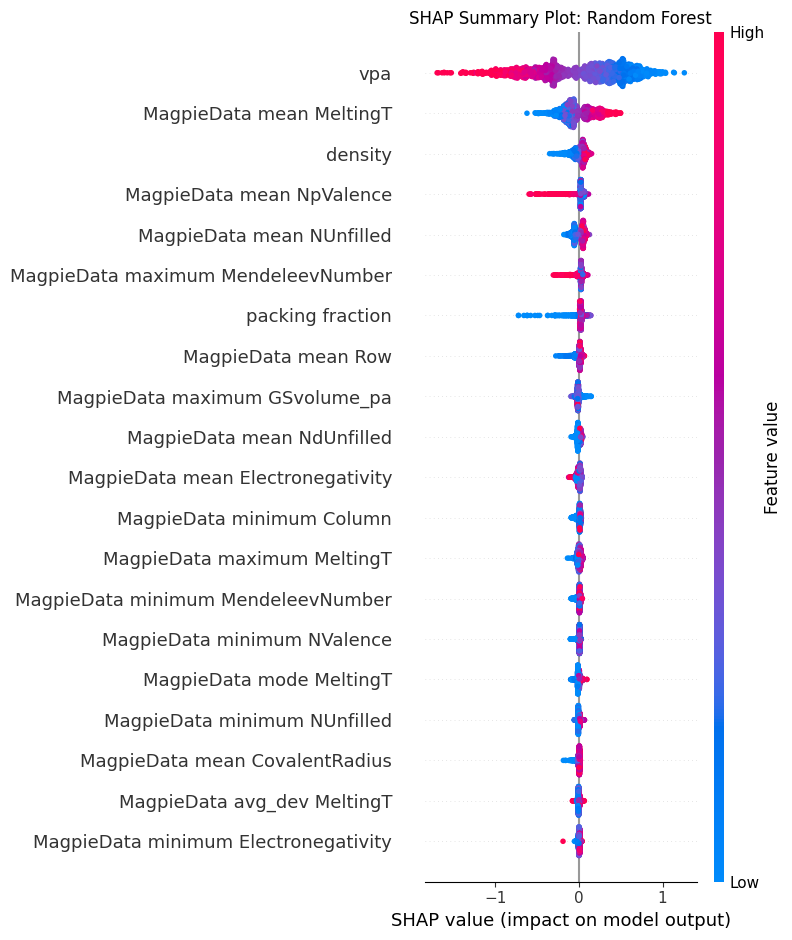

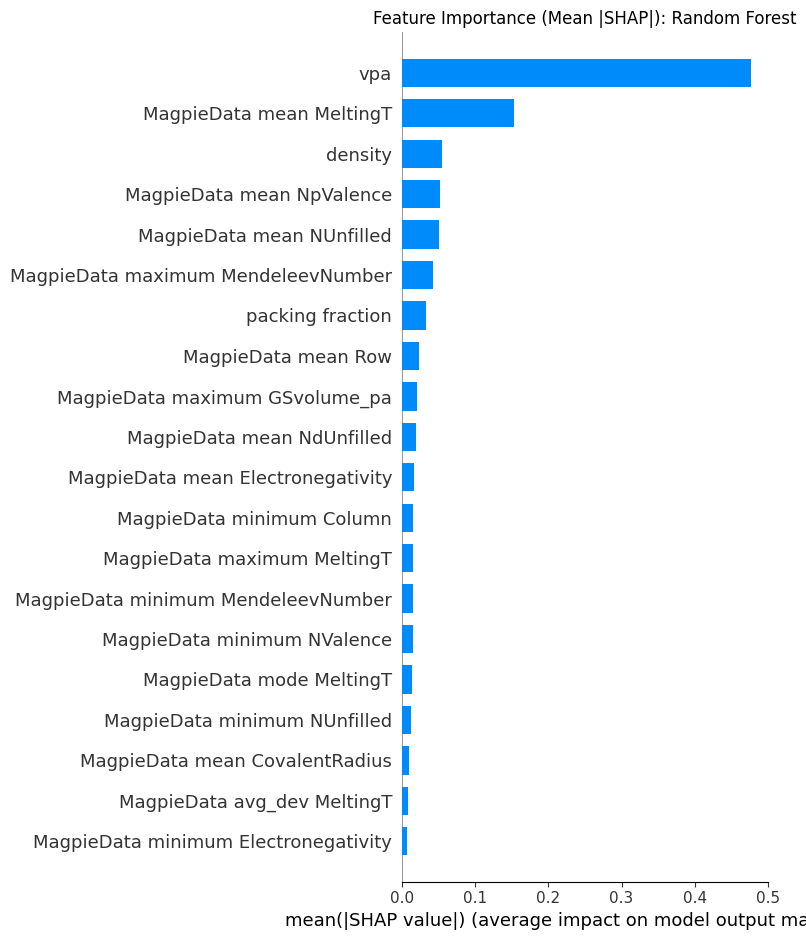


--- Calculating SHAP values for Gradient Boosting ---


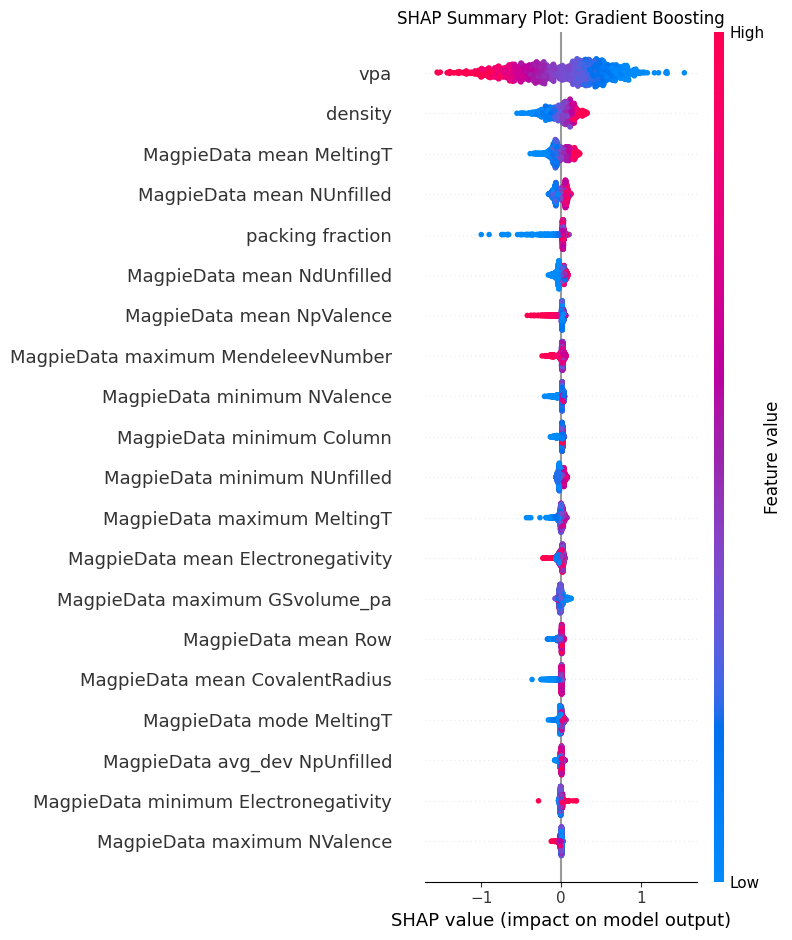

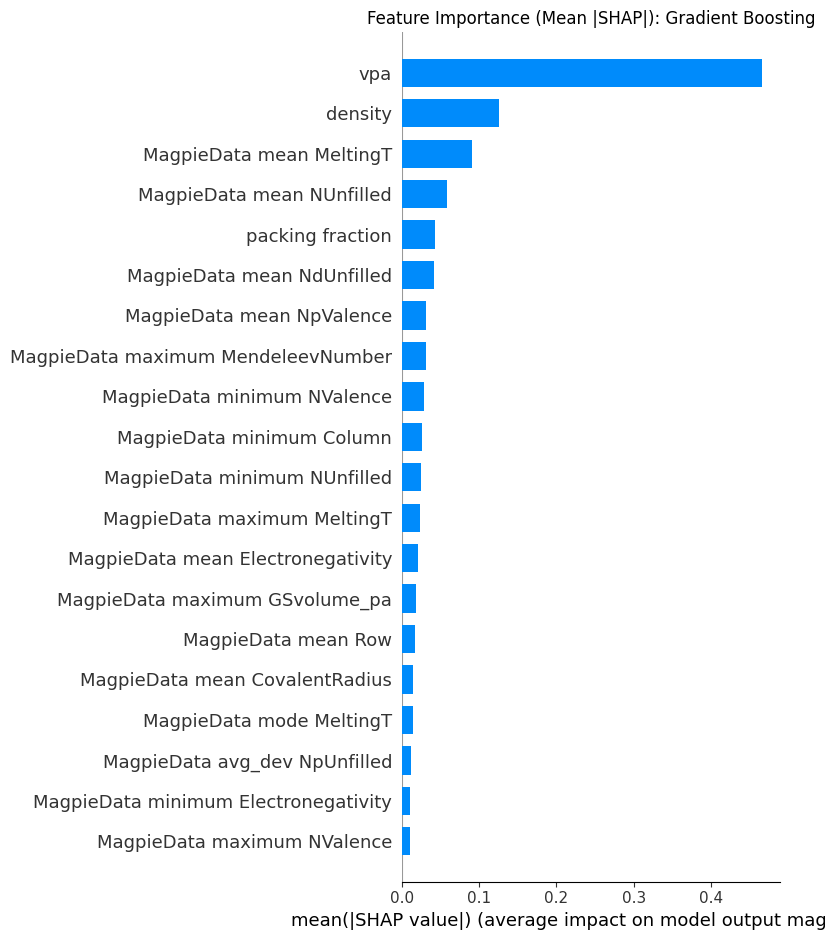


--- Calculating SHAP values for XGBoost ---


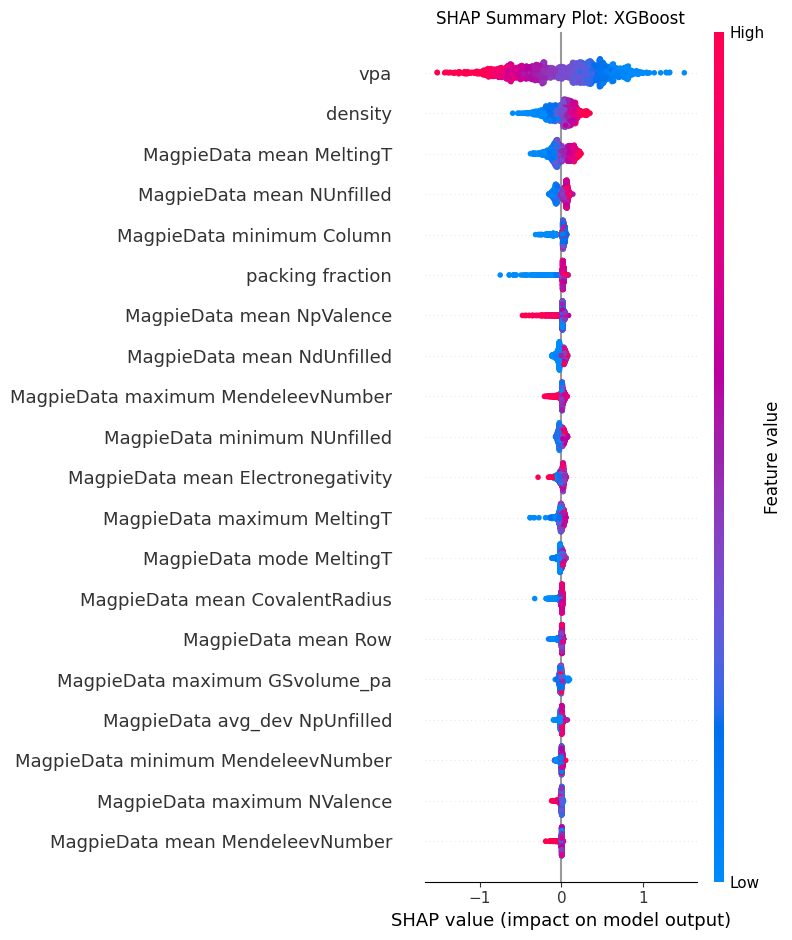

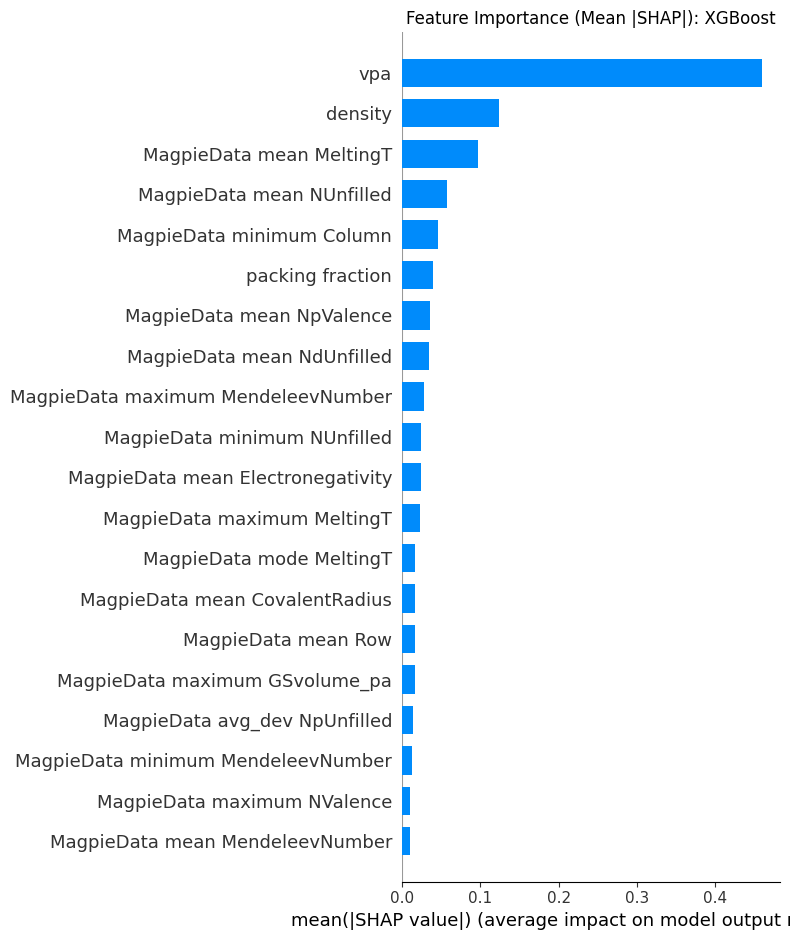


--- Calculating SHAP values for CatBoost ---


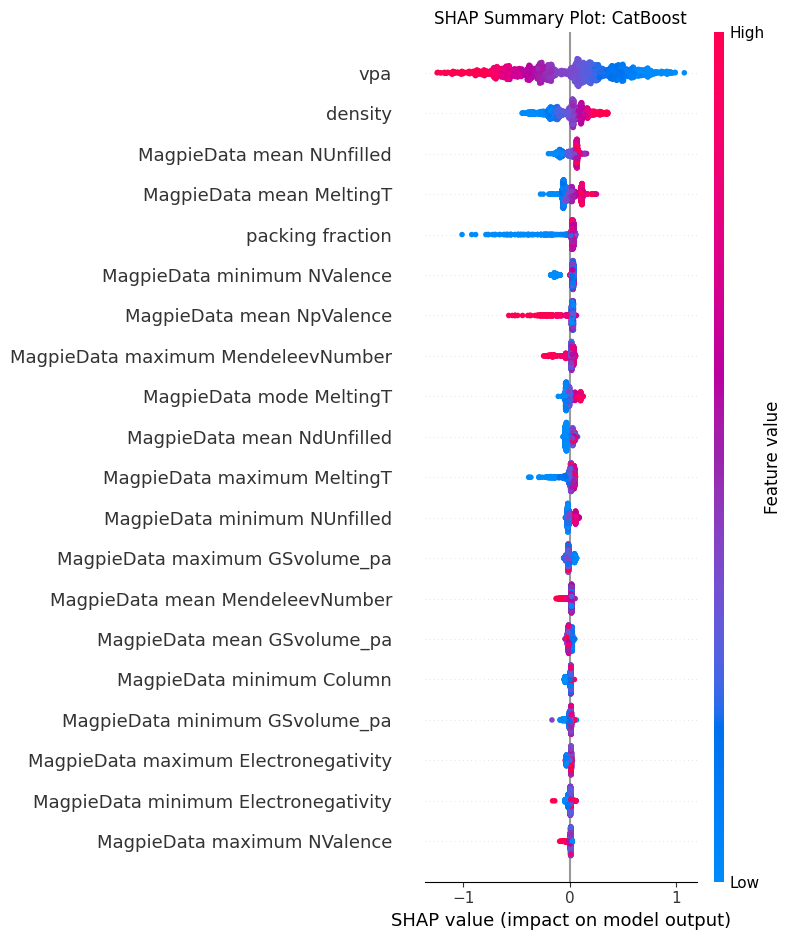

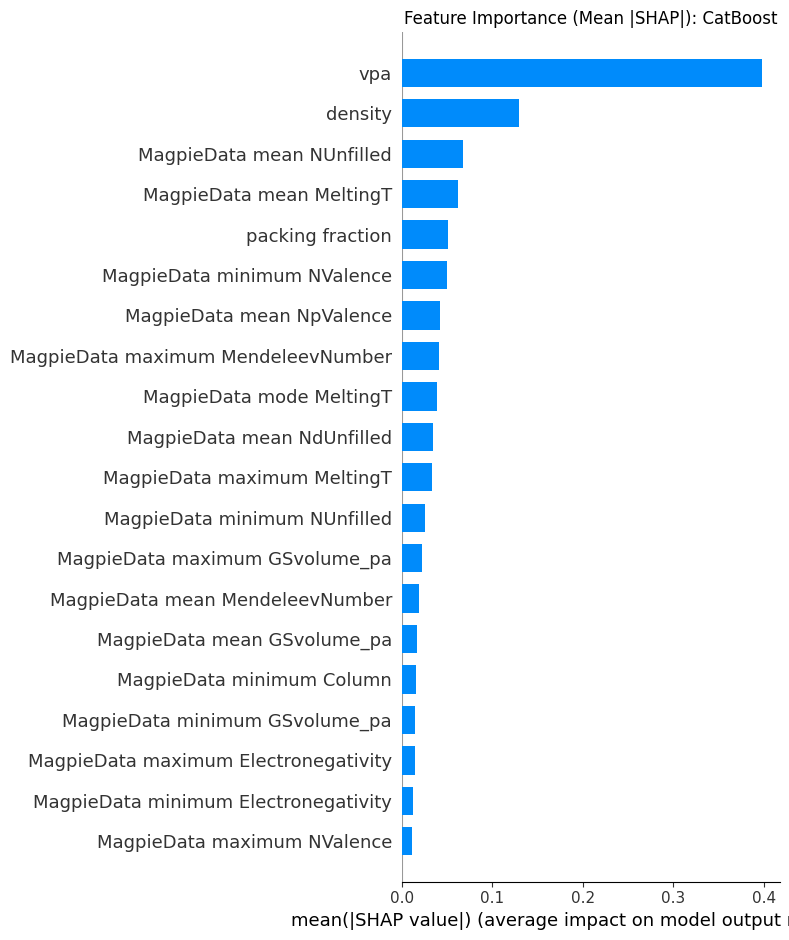

(<shap.explainers._tree.TreeExplainer at 0x7b32a1466210>,
 array([[-5.33477979e-03,  1.66797168e-03,  1.71947014e-04, ...,
          2.02672427e-02,  3.83300979e-01,  2.57419115e-02],
        [ 9.80102285e-04,  1.53613745e-03,  2.79974060e-04, ...,
          1.70186435e-02,  4.85164084e-01,  3.10384273e-02],
        [ 9.94215933e-04,  7.86554805e-04,  1.11045752e-04, ...,
         -1.15446922e-01,  1.74685750e-01,  2.78770347e-02],
        ...,
        [ 1.23642235e-03,  1.60331778e-03,  2.79974060e-04, ...,
         -9.26220081e-02,  2.86708040e-01,  2.72889110e-02],
        [ 1.59092697e-03, -3.63077664e-04,  1.26488107e-04, ...,
         -1.77130081e-01, -1.02054893e+00,  1.23682676e-02],
        [ 3.31528356e-03, -2.29396401e-03,  2.01568077e-04, ...,
          1.03470337e-01, -6.66578407e-01,  1.94687928e-02]]))

In [18]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Initialize JavaScript visualization (for Jupyter notebooks)
shap.initjs()

# 1. Define Feature Names
# We need the feature names list to make the plots interpretable.
# Based on your feature engineering step:
feature_names = feature_cols

# 2. Wrapper function for Tree-based SHAP analysis
def analyze_model_shap(model, X_data, feature_names, model_name):
    print(f"\n--- Calculating SHAP values for {model_name} ---")

    # Create the TreeExplainer
    # Note: feature_perturbation='interventional' is the default for some,
    # but 'tree_path_dependent' is faster for random forests usually.
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    # We use X_test_scaled here to explain predictions on unseen data
    # (You can also use X_train_scaled for global importance)
    shap_values = explainer.shap_values(X_data)

    # Handle dimensions: Some models (like GradientBoosting/RF) might return a list for regression
    # or a 3D array. We ensure we have a 2D array (samples x features).
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # --- Plot 1: Summary Plot (Beeswarm) ---
    # Shows feature importance AND feature effect (high/low values)
    plt.figure()
    plt.title(f"SHAP Summary Plot: {model_name}")
    shap.summary_plot(shap_values, X_data, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Bar Plot (Global Importance) ---
    # Shows mean absolute impact of each feature
    plt.figure()
    plt.title(f"Feature Importance (Mean |SHAP|): {model_name}")
    shap.summary_plot(shap_values, X_data, feature_names=feature_names, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    return explainer, shap_values

# 3. Analyze each Tree-based Model

# --- Random Forest ---
# Note: Sklearn RF can be slower with SHAP than XGB/CatBoost.
# We use a subset of test data (e.g., first 100-500 samples) if the dataset is massive,
# but for materials datasets, it's usually fine to use the whole X_test_scaled.
analyze_model_shap(best_rf, X_test_scaled, feature_names, "Random Forest")

# --- Gradient Boosting (Sklearn) ---
analyze_model_shap(best_gbr, X_test_scaled, feature_names, "Gradient Boosting")

# --- XGBoost ---
# XGBoost requires the model to be passed directly, sometimes stripped of sklearn wrapper
# But shap.TreeExplainer usually handles the sklearn wrapper fine.
analyze_model_shap(best_xgbr, X_test_scaled, feature_names, "XGBoost")

# --- CatBoost ---
analyze_model_shap(best_cbr, X_test_scaled, feature_names, "CatBoost")

# 4. Detailed Dependence Plot (Optional)
# If you find a specific feature is very important (e.g., "density" or "mean AtomicWeight"),
# you can plot how it interacts with the target.
# Replace 'feature_name_here' with an actual string from your feature_cols list.

# Example: Pick the top feature automatically
# Calculate mean abs shap values to find top feature index
# explainer_xgb = shap.TreeExplainer(best_xgbr)
# shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)
# top_feature_idx = np.abs(shap_values_xgb).mean(0).argmax()
# top_feature_name = feature_names[top_feature_idx]

# print(f"Creating dependence plot for top feature: {top_feature_name}")
# shap.dependence_plot(top_feature_name, shap_values_xgb, X_test_scaled, feature_names=feature_names)

In [16]:
# Load imputer and apply
imputer = joblib.load('imputer.pkl')
X = imputer.transform(X)

# Log transform y
y_log = np.log1p(y)

# Split data (same as training to match X_test_scaled)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Load scaler and scale X_test
scaler_X = joblib.load('scaler_x.pkl')
X_test_scaled = scaler_X.transform(X_test)

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re

# ... (Imports and model loading remain the same) ...

models = {
    'RandomForest': best_rf,
    'GradientBoosting': best_gbr,
    'XGBoost': best_xgbr,
    'CatBoost': best_cbr
}

for name, model in models.items():
    print(f"\nComputing SHAP for {name}...")
    explainer = shap.TreeExplainer(model)

    # 1. Get raw SHAP values
    shap_values_raw = explainer.shap_values(X_test_scaled)

    # Handle list case (e.g., multi-output)
    if isinstance(shap_values_raw, list):
        shap_values_array = shap_values_raw[0]
    else:
        shap_values_array = shap_values_raw

    # 2. Get the expected value (base value)
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[0] # Take the first element for single-output

    # 3. FIX: Create shap.Explanation object, including base_values
    shap_explanation = shap.Explanation(
        values=shap_values_array,
        base_values=expected_value, # Pass the expected value
        data=X_test_scaled,
        feature_names=feature_cols
    )

    # SHAP heatmap
    plt.figure(figsize=(12, 8))
    shap.plots.heatmap(shap_explanation, max_display=20, show=False)
    plt.title(f"SHAP Heatmap for {name}")
    plt.savefig(f'shap_heatmap_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Feature importance summary plot
    # Now this function will work correctly because shap_explanation contains base_values
    shap.summary_plot(shap_explanation, X_test_scaled, feature_names=feature_cols, show=False, max_display=20)
    plt.savefig(f'shap_summary_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Custom heatmap (No change needed here as it uses raw arrays/DataFrames)
    shap_df = pd.DataFrame(shap_values_array, columns=feature_cols)
    mean_abs = np.abs(shap_df).mean().sort_values(ascending=False)
    top_feats = mean_abs.head(20).index
    shap_top = shap_df[top_feats].T
    plt.figure(figsize=(12, 8))
    sns.heatmap(shap_top, cmap='coolwarm', center=0)
    plt.title(f"SHAP Values Heatmap (Top 20 Features) for {name}")
    plt.xlabel("Test Instances")
    plt.ylabel("Features")
    plt.savefig(f'shap_custom_heatmap_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()

print("SHAP analysis complete. Check saved figures.")


Computing SHAP for RandomForest...


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from ase import Atoms
from ase.eos import EquationOfState
from gpaw import GPAW, PW
from pymatgen.core import Structure, Composition, Lattice
from pymatgen.ext.matproj import MPRester
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load the imputer and scaler
imputer = joblib.load('imputer.pkl')
scaler_X = joblib.load('scaler_x.pkl')  # Corrected from 'scaler_x.pkl' to match 3rd code

# Load the trained models
best_rf = joblib.load('best_rf.pkl')  # Corrected from 'best_rf.pkl' to match 3rd code
best_svr = joblib.load('best_svr.pkl')
best_gbr = joblib.load('best_gbr.pkl')
best_xgbr = joblib.load('best_xgbr.pkl')
best_cbr = joblib.load('best_cbr.pkl')

# Define a list of 100 ceramic materials suitable for nuclear reactors
# Note: This is a curated list; in practice, you may query Materials Project or use your dataset
ceramic_materials = [
    {"formula": "Al2O3", "name": "Alumina"},
    {"formula": "SiC", "name": "Silicon Carbide"},
    {"formula": "ZrO2", "name": "Zirconia"},
    {"formula": "B4C", "name": "Boron Carbide"},
    {"formula": "Si3N4", "name": "Silicon Nitride"},
    {"formula": "TiC", "name": "Titanium Carbide"},
    {"formula": "ZrC", "name": "Zirconium Carbide"},
    {"formula": "WC", "name": "Tungsten Carbide"},
    {"formula": "TiN", "name": "Titanium Nitride"},
    {"formula": "ZrN", "name": "Zirconium Nitride"},
    # Add more ceramics (oxides, carbides, nitrides, borides) to reach 100
    # For brevity, we list 10 here; expand with Materials Project query or manual list
    # Examples: MgO, BeO, ThO2, UO2, BN, AlN, HfC, HfN, etc.
]

# Expand the list to 100 materials (placeholder; replace with actual query or list)
# For demonstration, repeat some entries and add placeholders
for i in range(10, 100):
    ceramic_materials.append({"formula": f"Ceramic{i}", "name": f"Placeholder Ceramic {i}"})

# Function to get Pymatgen Structure (placeholder; replace with actual structure retrieval)
def get_structure(formula):
    """
    Retrieve or create a Pymatgen Structure for a given formula.
    In practice, use Materials Project API or dataset structures.
    """
    try:
        # Example structures for known ceramics
        if formula == "Al2O3":
            lattice = Lattice.hexagonal(a=4.76, c=12.99)
            return Structure(lattice, ["Al", "Al", "O", "O", "O"],
                            [[0, 0, 0.352], [0, 0, 0.648], [0, 0, 0.25], [0, 0, 0.75], [0.333, 0.667, 0.083]])
        elif formula == "SiC":
            lattice = Lattice.cubic(4.36)
            return Structure(lattice, ["Si", "C"], [[0, 0, 0], [0.25, 0.25, 0.25]])
        elif formula == "ZrO2":
            lattice = Lattice.cubic(5.09)
            return Structure(lattice, ["Zr", "O", "O"], [[0, 0, 0], [0.25, 0.25, 0.25], [0.75, 0.75, 0.75]])
        elif formula == "B4C":
            lattice = Lattice.hexagonal(a=5.60, c=12.09)
            return Structure(lattice, ["B", "B", "B", "B", "C"],
                            [[0, 0, 0], [0.333, 0.667, 0.25], [0.667, 0.333, 0.75], [0, 0, 0.5], [0, 0, 0.25]])
        elif formula == "Si3N4":
            lattice = Lattice.hexagonal(a=7.75, c=5.62)
            return Structure(lattice, ["Si", "Si", "Si", "N", "N", "N", "N"],
                            [[0, 0, 0], [0.333, 0.667, 0.25], [0.667, 0.333, 0.75],
                             [0, 0, 0.25], [0.333, 0.667, 0.5], [0.667, 0.333, 0], [0, 0, 0.75]])
        # Add more specific structures as needed
        else:
            # Placeholder: cubic lattice for unknown ceramics
            return Structure(Lattice.cubic(5.0), [Composition(formula).elements[0]], [[0, 0, 0]])
    except Exception as e:
        print(f"Error creating structure for {formula}: {e}")
        return None

def predict_bulk_modulus(model, struct: Structure) -> float:
    """
    Predict bulk modulus using the given model and featurized structure.
    """
    try:
        comp_featurizer = ElementProperty.from_preset("magpie")
        comp_df = comp_featurizer.featurize_dataframe(pd.DataFrame({"composition": [struct.composition]}), "composition")
        comp_features = comp_df.drop(columns=["composition"])

        struct_featurizer = DensityFeatures()
        struct_df = struct_featurizer.featurize_dataframe(pd.DataFrame({"structure": [struct]}), "structure")
        struct_features = struct_df.drop(columns=["structure"])

        feature_df = pd.concat([comp_features, struct_features], axis=1)
        X_new = feature_df.values
        X_new_imputed = imputer.transform(X_new)
        X_new_scaled = scaler_X.transform(X_new_imputed)
        y_pred_log = model.predict(X_new_scaled)
        y_pred = np.expm1(y_pred_log)
        return y_pred[0]
    except Exception as e:
        print(f"Prediction error for structure: {e}")
        return np.nan

def calculate_bulk_modulus_with_gpaw(struct: Structure, kpts=(4, 4, 4), ecut=400, xc='PBE') -> float:
    """
    Calculate bulk modulus using GPAW by fitting energy-volume curve to Birch-Murnaghan EOS.
    Reduced kpts and ecut for faster computation; adjust for accuracy.
    """
    try:
        atoms = Atoms(symbols=[site.specie.symbol for site in struct],
                      positions=struct.cart_coords,
                      cell=struct.lattice.matrix,
                      pbc=True)
        calc = GPAW(mode=PW(ecut), xc=xc, kpts=kpts, txt=None)  # Silent output
        atoms.calc = calc
        volumes = []
        energies = []
        original_cell = atoms.get_cell()
        scales = np.linspace(0.94, 1.06, 5)  # Reduced to 5 points for speed
        for scale in scales:
            scaled_cell = original_cell * scale**(1/3)
            atoms.set_cell(scaled_cell, scale_atoms=True)
            try:
                energy = atoms.get_potential_energy()
                volumes.append(atoms.get_volume())
                energies.append(energy)
            except Exception as e:
                print(f"GPAW calculation failed for scale {scale}: {e}")
                continue
        if len(volumes) < 3:
            raise ValueError("Too few successful GPAW calculations to fit EOS.")
        eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
        v0, e0, B = eos.fit()
        conversion_factor = 160.21766208  # eV/Å^3 to GPa
        B_GPa = B * conversion_factor
        return B_GPa
    except Exception as e:
        print(f"GPAW error for structure: {e}")
        return np.nan

# Compute bulk modulus and deviations for all materials
results = []
models = {
    'Random Forest': best_rf,
    'SVR': best_svr,
    'Gradient Boosting': best_gbr,
    'XGBoost': best_xgbr,
    'CatBoost': best_cbr
}

for mat in ceramic_materials:
    formula = mat['formula']
    name = mat['name']
    print(f"Processing {name} ({formula})...")
    struct = get_structure(formula)
    if struct is None:
        continue
    try:
        gpaw_bm = calculate_bulk_modulus_with_gpaw(struct)
        if np.isnan(gpaw_bm):
            continue
        result = {'Material': name, 'Formula': formula, 'GPAW Bulk Modulus (GPa)': gpaw_bm}
        for model_name, model in models.items():
            pred_bm = predict_bulk_modulus(model, struct)
            deviation = (abs(gpaw_bm - pred_bm) / gpaw_bm * 100) if not np.isnan(pred_bm) else np.nan
            result[f'{model_name} Prediction (GPa)'] = pred_bm
            result[f'{model_name} Error (%)'] = deviation
        results.append(result)
    except Exception as e:
        print(f"Error processing {formula}: {e}")
        continue

# Create DataFrame
results_df = pd.DataFrame(results)

# Save results to CSV
results_df.to_csv('ceramic_bulk_modulus_comparison.csv', index=False)

# Print summary statistics
print("\nSummary of Error Percentages:")
for model_name in models.keys():
    error_col = f'{model_name} Error (%)'
    mean_error = results_df[error_col].mean()
    median_error = results_df[error_col].median()
    std_error = results_df[error_col].std()
    print(f"{model_name}:")
    print(f"  Mean Error: {mean_error:.2f}%")
    print(f"  Median Error: {median_error:.2f}%")
    print(f"  Std Dev of Error: {std_error:.2f}%")

# Plot error distributions
plt.figure(figsize=(10, 6))
for model_name in models.keys():
    errors = results_df[f'{model_name} Error (%)'].dropna()
    plt.hist(errors, bins=30, alpha=0.4, label=model_name, density=True)
plt.xlabel('Error Percentage (%)')
plt.ylabel('Density')
plt.title('Error Distribution of ML Models vs GPAW')
plt.legend()
plt.savefig('error_distribution.png')
plt.close()

# Display first few rows of results
print("\nFirst 5 Results:")
print(results_df.head().to_string())

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pymatgen.core import Structure, Lattice, Composition
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures

# ----------------------------
# Load preprocessors and models
# ----------------------------
imputer = joblib.load('imputer.pkl')
scaler_X = joblib.load('scaler_x.pkl')

models = {
    'Random Forest': joblib.load('best_rf.pkl'),
    'SVR': joblib.load('best_svr.pkl'),
    'Gradient Boosting': joblib.load('best_gbr.pkl'),
     'XGBoost': joblib.load('best_xgbr.pkl'),
    'CatBoost': joblib.load('best_cbr.pkl'),
}

# ----------------------------
# Real ceramic materials
# ----------------------------
ceramic_materials = [
    {"formula": "Al2O3", "name": "Alumina"},
    {"formula": "SiC", "name": "Silicon Carbide"},
    {"formula": "ZrO2", "name": "Zirconia"},
    {"formula": "B4C", "name": "Boron Carbide"},
    {"formula": "Si3N4", "name": "Silicon Nitride"},
    {"formula": "TiC", "name": "Titanium Carbide"},
    {"formula": "ZrC", "name": "Zirconium Carbide"},
    {"formula": "WC", "name": "Tungsten Carbide"},
    {"formula": "TiN", "name": "Titanium Nitride"},
    {"formula": "ZrN", "name": "Zirconium Nitride"},
    {"formula": "HfC", "name": "Hafnium Carbide"},
    {"formula": "BN", "name": "Boron Nitride"},
    {"formula": "MgO", "name": "Magnesia"},
    {"formula": "AlN", "name": "Aluminum Nitride"},
    {"formula": "BeO", "name": "Beryllium Oxide"},
    {"formula": "ThO2", "name": "Thorium Dioxide"},
    {"formula": "UO2", "name": "Uranium Dioxide"},
]

# ----------------------------
# Minimal structure generator
# ----------------------------
def get_structure(formula):
    try:
        if formula == "Al2O3":
            lattice = Lattice.hexagonal(a=4.76, c=12.99)
            return Structure(lattice, ["Al", "Al", "O", "O", "O"],
                             [[0, 0, 0.352], [0, 0, 0.648],
                              [0, 0, 0.25], [0, 0, 0.75], [0.333, 0.667, 0.083]])
        elif formula == "SiC":
            lattice = Lattice.cubic(4.36)
            return Structure(lattice, ["Si", "C"], [[0, 0, 0], [0.25, 0.25, 0.25]])
        elif formula == "ZrO2":
            lattice = Lattice.cubic(5.09)
            return Structure(lattice, ["Zr", "O", "O"],
                             [[0, 0, 0], [0.25, 0.25, 0.25], [0.75, 0.75, 0.75]])
        else:
            return Structure(Lattice.cubic(5.0),
                             [el.symbol for el in Composition(formula).elements],
                             np.linspace([0,0,0],[0.5,0.5,0.5], len(Composition(formula).elements)))
    except Exception as e:
        print(f"Error building structure for {formula}: {e}")
        return None

# ----------------------------
# Prediction function
# ----------------------------
def predict_bulk_modulus(model, struct):
    try:
        # Featurization
        comp_featurizer = ElementProperty.from_preset("magpie")
        df_comp = pd.DataFrame({"composition": [struct.composition]})
        df_comp = comp_featurizer.featurize_dataframe(df_comp, "composition")
        comp_feats = df_comp.drop(columns=["composition"])

        struct_featurizer = DensityFeatures()
        df_struct = pd.DataFrame({"structure": [struct]})
        df_struct = struct_featurizer.featurize_dataframe(df_struct, "structure")
        struct_feats = df_struct.drop(columns=["structure"])

        features = pd.concat([comp_feats, struct_feats], axis=1)
        X = features.values

        # Ensure consistent shape
        X_imp = imputer.transform(X)
        X_scaled = scaler_X.transform(X_imp)

        y_pred = model.predict(X_scaled)
        # No log1p transform unless confirmed
        return float(y_pred[0])

    except Exception as e:
        print(f"Prediction failed: {e}")
        return np.nan

# ----------------------------
# Main loop
# ----------------------------
results = []
for mat in ceramic_materials:
    formula = mat["formula"]
    name = mat["name"]
    print(f"Processing {name} ({formula})...")

    struct = get_structure(formula)
    if struct is None:
        continue

    row = {"Material": name, "Formula": formula}

    for model_name, model in models.items():
        pred = predict_bulk_modulus(model, struct)
        row[f"{model_name} Prediction (GPa)"] = pred

    results.append(row)

# ----------------------------
# Results & Visualization
# ----------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("ceramic_bulk_modulus_predictions.csv", index=True)

print("\nPredictions saved to 'ceramic_bulk_modulus_predictions.csv'")
print(results_df.head())

plt.figure(figsize=(10, 6))
for model_name in models.keys():
    vals = results_df[f"{model_name} Prediction (GPa)"].dropna()
    plt.hist(vals, bins=20, alpha=0.4, label=model_name, density=True)
plt.xlabel("Predicted Bulk Modulus (GPa)")
plt.ylabel("Density")
plt.title("Distribution of Predicted Bulk Moduli")
plt.legend()
plt.tight_layout()
plt.savefig("bulk_modulus_predictions.png")
plt.close()


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import joblib

# Assume X_test_scaled, y_test (log), X, y (original or log as per context) are defined earlier
# Load tuned models and scaler (trained and saved via the training code)

scaler_X = joblib.load('scaler_x.pkl')
best_rf = joblib.load('best_rf.pkl')
best_svr = joblib.load('best_svr.pkl')
best_cat = joblib.load('best_cbr.pkl')
best_xgb = joblib.load('best_xgbr.pkl')
best_gbr = joblib.load('best_gbr.pkl')

# Dictionary of models
models = {
    'RF': best_rf,
    'SVR': best_svr,
    'CatBoost': best_cat,
    'XGBoost': best_xgb,
    'GBR': best_gbr
}

# Predict on test set for all models
predictions = {}
y_test_orig = np.expm1(y_test)  # Inverse log transform for actual values

for name, model in models.items():
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)  # Inverse log transform
    predictions[name] = y_pred

    # Metrics on test set
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    print(f"{name} Test RMSE: {rmse:.4f} GPa, R²: {r2:.4f}")

# One combined parity plot on test set for all models
plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'r', 'c', 'm']
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.scatter(y_test_orig, y_pred, alpha=0.5, label=name, color=colors[i])
max_val = max(y_test_orig.max(), max(max(pred) for pred in predictions.values()))
plt.plot([0, max_val], [0, max_val], "k--", label='Ideal Parity')
plt.xlabel("True Bulk Modulus (GPa)")
plt.ylabel("Predicted Bulk Modulus (GPa)")
plt.title("Parity Plot on Test Set for All Models")
plt.legend()
plt.grid(True)
plt.show()

# Combined deviation plot on test set for all models
plt.figure(figsize=(6, 6))
for i, (name, y_pred) in enumerate(predictions.items()):
    deviations_test = y_pred - y_test_orig
    plt.scatter(y_test_orig, deviations_test, alpha=0.5, label=name, color=colors[i])
plt.axhline(0, color='k', linestyle='--', label='Ideal Prediction')
plt.xlabel("Actual Bulk Modulus (GPa)")
plt.ylabel("Deviation (Predicted - Actual) (GPa)")
plt.title("Deviation Plot on Test Set for All Models")
plt.grid(True)
plt.legend()
plt.show()

# Optionally, for comparison: Deviation plot on up to 1000 random samples from the full dataset
# (This may include training data, so it's not a pure evaluation but can show overall model behavior)
# Here, shown only for RF to avoid clutter; can be extended similarly if needed
num_materials = min(1000, len(X))
indices = random.sample(range(len(X)), num_materials)

# Extract the corresponding features and actual values
X_random = X[indices]
y_random_actual = np.expm1(y_log[indices])  # Assuming y_log is the log-transformed full target; adjust if y is original

# Scale features and predict (for RF only in this optional part)
X_random_scaled = scaler_X.transform(X_random)
y_random_log_pred = best_rf.predict(X_random_scaled)
y_random_pred = np.expm1(y_random_log_pred)

# Calculate deviations
deviations_random = y_random_pred - y_random_actual

# Plot the deviation graph for random samples
plt.figure(figsize=(10, 6))
plt.scatter(y_random_actual, deviations_random, alpha=0.5, label='RF Deviation')
plt.axhline(0, color='r', linestyle='--', label='Ideal Prediction')
plt.xlabel("Actual Bulk Modulus (GPa)")
plt.ylabel("Deviation (Predicted - Actual) (GPa)")
plt.title(f"Deviation Plot for {num_materials} Random Materials from Full Dataset (RF)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
pip install ase

In [ ]:
%%capture
!apt install python3-mpi4py cython3 libxc-dev gpaw-data
!pip -q install gpaw

In [ ]:
from ase import Atoms
from ase.optimize import BFGS
from ase.constraints import UnitCellFilter
from ase.eos import EquationOfState
from ase.units import kJ
from gpaw import GPAW, PW
import numpy as np
from scipy.optimize import curve_fit

# Define the cubic BC2N structure (primitive cell with 4 atoms, P-43m)
a = 3.642  # Initial guess lattice constant in Å (from literature)
cell = np.diag([a, a, a])  # Cubic cell
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
symbols = 'BCNC'
atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=True)

# Set up GPAW calculator for relaxation
calc = GPAW(
    mode=PW(600),          # Higher plane-wave cutoff for convergence
    kpts=(10, 10, 10),     # Denser k-point grid
    xc='PBE',              # Exchange-correlation functional
    txt='gpaw_relax.txt',
    setups={'B': 'paw', 'C': 'paw', 'N': 'paw'},  # Explicit PAW setups
    convergence={'energy': 1e-3, 'density': 1e-2}  # Tighter convergence
)

# Attach calculator and optimize structure (including cell)
atoms.calc = calc
ucf = UnitCellFilter(atoms)  # Allows cell relaxation while preserving symmetry
dyn = BFGS(ucf, trajectory='relax.traj', logfile='relax.log')
dyn.run(fmax=0.05)  # Optimize until forces < 0.05 eV/Å

# Get optimized lattice constant
optimized_a = atoms.get_cell()[0, 0]
print(f'Optimized lattice constant: {optimized_a:.3f} Å')

# Now compute energy-volume curve around the optimized structure
volumes = []
energies = []
scales = np.linspace(0.85, 1.25, 4)  # Wider range to capture minimum (±25%)

for scale in scales:
    scaled_atoms = atoms.copy()
    scaled_atoms.set_cell(atoms.get_cell() * scale, scale_atoms=True)
    calc = GPAW(
        mode=PW(600),
        kpts=(10, 10, 10),
        xc='PBE',
        txt=f'gpaw_scale_{scale:.2f}.txt',
        setups={'B': 'paw', 'C': 'paw', 'N': 'paw'},
        convergence={'energy': 1e-3, 'density': 1e-3}
    )
    scaled_atoms.calc = calc
    e = scaled_atoms.get_potential_energy()
    energies.append(e)
    volumes.append(scaled_atoms.get_volume())
    print(f'Scale {scale:.2f}: Volume = {volumes[-1]:.2f} Å³, Energy = {e:.4f} eV')

# Fit the equation of state (Birch-Murnaghan)
eos = EquationOfState(volumes, energies, eos='birchmurnaghan')

try:
    v0, e0, B = eos.fit()  # Try default fit
except RuntimeError:
    # If fails, manual fit with higher maxfev and initial guess
    def birchmurnaghan(v, e0, B0, BP, v0):  # BP fixed to 4
        eta = (v0 / v)**(2.0 / 3.0)
        return e0 + (9 * v0 * B0 / 16) * (((eta - 1)**3 * BP) + ((eta - 1)**2 * (6 - 4 * eta)))

    # Initial guess: e0 ~ min energy, B0 ~ rough estimate (e.g., 4 eV/Å³), BP=4, v0 ~ max volume
    p0 = [min(energies), 4.0, 4.0, max(volumes)]
    popt, _ = curve_fit(birchmurnaghan, volumes, energies, p0=p0, maxfev=5000)
    e0, B, BP, v0 = popt
    print('Used manual curve_fit with higher maxfev.')

# Convert bulk modulus to GPa (correct factor: 1 eV/Å³ ≈ 160.217662 GPa)
B_GPa = B * 160.217662

print(f'Equilibrium volume: {v0:.2f} Å³')
print(f'Equilibrium energy: {e0:.4f} eV')
print(f'Bulk modulus: {B_GPa:.1f} GPa')

# Optional: Plot the EOS
eos.plot('bc2n_eos.png')

In [ ]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR  # Import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Assume X and y

# Log-transform
y_log = np.log1p(y)

# Timing
total_start = time.time()

# Split
split_start = time.time()
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
split_end = time.time()
print(f"Data splitting time: {split_end - split_start:.4f} seconds")

# Scale features (critical for SVR)
scale_start = time.time()
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
scale_end = time.time()
print(f"Feature scaling time: {scale_end - scale_start:.4f} seconds")

# Model
svr = SVR(kernel='rbf')

# Hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Grid search
grid_start = time.time()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_squared_error")
grid_search.fit(np.vstack([X_train_scaled, X_val_scaled]), np.hstack([y_train, y_val]))
grid_end = time.time()
grid_time = grid_end - grid_start
print(f"Grid search fitting time: {grid_time:.4f} seconds")

# Best model
best_svr = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")

# Save
joblib.dump(best_svr, 'best_svr.pkl')
joblib.dump(scaler_X, 'scaler_x.pkl')

# Total time
total_end = time.time()
total_time = total_end - total_start
print(f"Total execution time: {total_time:.4f} seconds")

# Efficiency
num_fits = len(param_grid['C']) * len(param_grid['epsilon']) * len(param_grid['gamma']) * 5
time_per_fit = grid_time / num_fits if num_fits > 0 else 0
print(f"Average time per model fit: {time_per_fit:.4f} seconds")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_svr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_svr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the optimized lattice constant
optimized_a = 3.979  # Optimized lattice constant in Å from GPAW
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_svr(struct)
print(f"Predicted Bulk Modulus for BC2N using SVR: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
pip install catboost

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_cbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_cbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the optimized lattice constant
optimized_a = 3.979  # Optimized lattice constant in Å from GPAW
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_cbr(struct)
print(f"Predicted Bulk Modulus for BC2N using cbr: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_gbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_gbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the optimized lattice constant
optimized_a = 3.979  # Optimized lattice constant in Å from GPAW
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_gbr(struct)
print(f"Predicted Bulk Modulus for BC2N using gbr: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_xgbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_xgbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the optimized lattice constant
optimized_a = 3.979  # Optimized lattice constant in Å from GPAW
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_xgbr(struct)
print(f"Predicted Bulk Modulus for BC2N using xgbr: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_svr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_svr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the correct optimized lattice constant from v0
v0 = 32.263  # Equilibrium volume from GPAW EOS fit
optimized_a = v0 ** (1/3)  # Correct lattice constant ≈ 3.183 Å
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_svr(struct)
print(f"Predicted Bulk Modulus for BC2N using SVR: {predicted_bulk_modulus:.2f} GPa")

In [ ]:

import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_cbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained cbr model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_cbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the correct optimized lattice constant from v0
v0 = 32.263  # Equilibrium volume from GPAW EOS fit
optimized_a = v0 ** (1/3)  # Correct lattice constant ≈ 3.183 Å
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_cbr(struct)
print(f"Predicted Bulk Modulus for BC2N using cbr: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_gbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_gbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the correct optimized lattice constant from v0
v0 = 32.263  # Equilibrium volume from GPAW EOS fit
optimized_a = v0 ** (1/3)  # Correct lattice constant ≈ 3.183 Å
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_gbr(struct)
print(f"Predicted Bulk Modulus for BC2N using gbr: {predicted_bulk_modulus:.2f} GPa")

In [ ]:
import pandas as pd
import joblib
import numpy as np
from pymatgen.core import Structure, Lattice
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure import DensityFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Function to predict bulk modulus using the trained SVR model
def predict_bulk_modulus_with_xgbr(struct: Structure) -> float:
    """
    Predict bulk modulus using the trained SVR model.
    """
    # Load pre-trained imputer, scaler, and model (assuming they are saved from previous training)
    try:
        imputer = joblib.load('imputer.pkl')
        scaler = joblib.load('scaler_x.pkl')
        model = joblib.load('best_xgbr.pkl')
    except FileNotFoundError:
        raise FileNotFoundError("Trained model files not found. Ensure they are saved from previous training.")

    # Featurize the input structure
    comp = struct.composition
    df_new = pd.DataFrame({'composition': [comp], 'structure_obj': [struct]})

    ep_feat = ElementProperty.from_preset("magpie", impute_nan=True)  # Suppress warning
    df_comp = ep_feat.featurize_dataframe(df_new, col_id="composition", ignore_errors=True)

    dens_feat = DensityFeatures()
    df_struct = dens_feat.featurize_dataframe(df_comp, "structure_obj", ignore_errors=True)

    to_drop = ["composition", "structure_obj"]
    feature_cols = df_struct.columns.difference(to_drop)
    X_new = df_struct[feature_cols].values

    # Apply imputation and scaling
    X_new_imp = imputer.transform(X_new)
    X_new_scaled = scaler.transform(X_new_imp)

    # Predict (log-transformed) and inverse transform
    y_log_pred = model.predict(X_new_scaled)
    y_pred = np.expm1(y_log_pred)[0]

    return y_pred

# Define the cubic BC2N structure using the correct optimized lattice constant from v0
v0 = 32.263  # Equilibrium volume from GPAW EOS fit
optimized_a = v0 ** (1/3)  # Correct lattice constant ≈ 3.183 Å
lattice = Lattice.cubic(optimized_a)
positions = [
    [0.0, 0.0, 0.0],      # B
    [0.25, 0.25, 0.25],   # C
    [0.5, 0.5, 0.5],      # N
    [0.75, 0.75, 0.75]    # C
]
species = ["B", "C", "N", "C"]
struct = Structure(lattice, species, positions)

# Predict the bulk modulus
predicted_bulk_modulus = predict_bulk_modulus_with_xgbr(struct)
print(f"Predicted Bulk Modulus for BC2N using xgbr: {predicted_bulk_modulus:.2f} GPa")